# Data loading

This notebook is for data extraction, inspection and cleaning only. No filtering, resampling or feature extraction is done here.



## Table of contents

1. [Original scripts](#1-original-scripts-provided-by-the-professor-in-scripts)
2. [This notebook](#2-this-notebook)
    - 2.1. [What stays the same](#21-what-stays-the-same)
    - 2.2. [What changed](#22-what-changed)
3. [Imports](#3-imports)
4. [Configuration](#4-configuration)
5. [Helpers](#5-helpers)
6. [Readers](#6-readers)
7. [File inventory](#7-file-inventory)
8. [Build the dataset index](#8-build-the-dataset-index)
9. [Metadata tables](#9-metadata-tables)
10. [Load a recording](#10-load-a-recording)
11. [Dataset summary](#11-dataset-summary)


### 1. Original scripts (provided by the professor, in `scripts/`)
[[go back to the topic]](#table-of-contents)

Loads both acquisition formats into one common structure:

| Patients | App | Location | ECG | PCG |
|---|---|---|---|---|
| 1 - 108 | Rijuven | files directly in the dataset root | `.raw` (comma-separated values) | `.mp3` |
| 109+ | New app (CardioSleeve) | one folder per patient | `.csv` with header (`Cardiac_signal=ECG`) | `.csv` with header (`Cardiac_signal=STE`) |



---


**`Open_ECG_PCG_Rijuven.ipynb`** (patients 1 - 108)
Opens one hardcoded recording (`1_AV`) and plots it:
- PCG `.mp3` read in two ways: `librosa.load(sr=None)` and `soundfile.read` (the recommended one, keeps the native sampling rate)
- ECG `.raw` read as text, split by commas, converted to floats, plotted at a hardcoded 500 Hz

**`Open_ECG_PCG_new_app.ipynb`** (patients 109+)
Opens one hardcoded ECG CSV and one PCG CSV, then:
- prints the 7-line header (`key=value`)
- keeps only rows starting with `'2023'` and joins their samples into one list of ints
- builds the time axis with a loop and plots with Matplotlib and Plotly
- final function `read_ecg_pcg_file(csv_file, sample_rate, signal_type)`: prints the header and duration and shows a Plotly plot (sampling rate passed by hand)


### 2. This notebook
[[go back to the topic]](#table-of-contents)

Runs over the whole dataset, it finds every recording, pairs ECG with PCG, loads them into a common `Recording` object and summarizes data quality.


#### 2.1. What stays the same
[[go back to the topic]](#2-this-notebook)

- Same understanding of both formats: `key=value` header lines, then one packet per row (timestamp + samples), with packets concatenated in file order
- PCG `.mp3` read with `soundfile` at its native rate, with `librosa.load(sr=None)` as the alternative
- Rijuven ECG assumed to be 500 Hz (not stored in the `.raw` file)
- Signals kept in raw units (ADC counts / decoded audio), no scaling or preprocessing



#### 2.2. What changed
[[go back to the topic]](#2-this-notebook)

**Scope**
- Processes the whole dataset instead of one hardcoded file, the path is set once in `DATA_ROOT`
- Builds an index of all recordings, Rijuven files paired by `patient_site` (`1_AV.raw` + `1_AV.mp3`), new app files paired by the timestamp in the filename (ECG + STE)
- Reports files that don't match the expected naming, and recordings missing ECG or PCG

**Reading fixes**
- Data rows detected with a timestamp pattern (`YYYY-MM-DD HH:MM:SS`) instead of `startswith('2023')`, which silently dropped recordings from other years
- Sampling rate, packet size and packet rate read from the CSV header instead of being passed by hand
- Files read as UTF-8 with a Latin-1 fallback (fixes `TricÃºspide` -> `Tricúspide`)
- Rijuven `.raw` split on commas and whitespace, so line breaks or trailing commas don't break parsing
- Stereo `.mp3` averaged to mono
- Samples stored as `float64` NumPy arrays instead of Python lists
- Time axis computed as `np.arange(n) / fs` instead of a cumulative loop (faster, and avoids floating-point drift)

**Harmonization**
- Valve names unified across apps: `AV`/`Aórtica` -> `AV`, `MV`/`Mitral` -> `MV`, `PV`/`Pulmonar` -> `PV`, `TV`/`Tricúspide` -> `TV`
- In the new app the valve is often only filled in one of the two files (the PCG says `NaN`), so it is taken from whichever file has it

**Structure**
- Loading separated from plotting: readers return a `Signal` (data, fs, metadata) and `load_recording()` returns a `Recording` with both signals
- `plot_recording()` shows ECG and PCG on a shared time axis (Matplotlib only; Plotly is not used)

**Quality checks (new)**
- Packets with a size different from `Packages_size`
- Gaps between packet timestamps longer than 1.5x the expected interval (lost packets)
- Fraction of PCG samples at the ADC limits (0 / 4095, assuming 12-bit), which indicates saturation
- ECG vs PCG duration mismatch per recording
- Summary table of every recording, with the ones worth a closer look flagged

### 3. Imports
[[go back to the top]](#table-of-contents)

In [14]:
from __future__ import annotations

import re
import unicodedata
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import filecmp
import soundfile as sf

### 4. Configuration
[[go back to the top]](#table-of-contents)

In [2]:
# Project root: first folder, from the notebook location upwards, that contains a "data" folder
PROJECT_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / "data").is_dir()), Path.cwd())

# Dataset root: Rijuven files, patient folders 109+, metadata spreadsheets and other folders
DATA_ROOT = PROJECT_ROOT / "data" / "DatasetCHVNGE"  

# The Rijuven .raw files do not store the sampling rate, 500 Hz comes from the original script
RIJUVEN_ECG_FS = 500

# Full-scale value of the new app ADC (12-bit), used to detect clipping
NEW_APP_ADC_MAX = 4095

assert DATA_ROOT.is_dir(), f"DATA_ROOT not found: {DATA_ROOT}"
print("Dataset root:", DATA_ROOT)

Dataset root: c:\Users\aleja\OneDrive\Documentos\GitHub\cardio-trimodal-align\data\DatasetCHVNGE


### 5. Helpers
[[go back to the top]](#table-of-contents)

In [3]:
# Map every valve spelling used by both apps to a common code
SITE_MAP = {
    "av": "AV", "aortica": "AV", "aortic": "AV",
    "mv": "MV", "mitral": "MV",
    "pv": "PV", "pulmonar": "PV", "pulmonary": "PV",
    "tv": "TV", "tricuspide": "TV", "tricuspid": "TV",
}


def strip_accents(text: str) -> str:
    """Remove accents so 'Tricúspide' and 'Tricuspide' compare equal."""
    return unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")


def normalize_site(name: str | None) -> str | None:
    """Return the common valve code, None for empty/NaN, or the original name if unknown."""
    if name is None:
        return None
    clean = strip_accents(str(name)).strip().lower()
    if clean in ("", "nan", "none"):
        return None
    return SITE_MAP.get(clean, str(name))


def read_text(path: Path) -> str:
    """Read a text file as UTF-8, falling back to Latin-1 for older exports."""
    try:
        return path.read_text(encoding="utf-8-sig")
    except UnicodeDecodeError:
        return path.read_text(encoding="latin-1")


def parse_number(value: str | None) -> float | None:
    """Extract the number from header values such as '500Hz' or '125samples'."""
    if value is None:
        return None
    match = re.search(r"[-+]?\d+(?:\.\d+)?", value)
    return float(match.group()) if match else None

In [4]:
# File name patterns of both apps
RIJUVEN_RE = re.compile(r"^(?P<patient>\d+)_(?P<site>[^_.]+)\.(?P<ext>raw|mp3)$", re.IGNORECASE)
NEW_APP_RE = re.compile(
    r"^(?P<prefix>[^_]+)_(?P<valve>.+?)_(?P<signal>ECG|STE|PCG)_(?P<stamp>.+)\.csv$", re.IGNORECASE
)


def is_multiscope_csv(path: Path) -> bool:
    """True if the file starts with the Multiscope signal header (reads only the first bytes)."""
    try:
        with open(path, "rb") as f:
            head = f.read(2048).decode("utf-8", errors="ignore").lstrip("\ufeff")
    except OSError:
        return False
    return head.startswith("Multiscope") or "Cardiac_signal=" in head


def read_csv_any(path: Path, **kwargs) -> pd.DataFrame:
    """Read a generic CSV, guessing the separator (, or ;) and the encoding."""
    for encoding in ("utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(path, sep=None, engine="python", encoding=encoding, **kwargs)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"Could not decode {path}")

### 6. Readers
[[go back to the top]](#table-of-contents)

In [5]:
class Signal:
    """Container for one signal: samples, sampling rate and extra information."""

    def __init__(self, data, fs, meta=None):
        self.data = data                                 # samples (NumPy array)
        self.fs = fs                                     # sampling rate in Hz
        self.meta = meta if meta is not None else {}     # header, quality checks, etc.

    def duration(self):
        """Signal length in seconds."""
        return len(self.data) / self.fs

**For the new app**

In [6]:
# Data rows start with a timestamp such as "2023-11-29 11:31:13.7450"
TIMESTAMP_RE = re.compile(r"^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}(?:\.\d+)?")


def read_new_app_csv(path: Path) -> Signal:
    """Read a Multiscope CSV (header lines 'key=value', then one packet per row: timestamp, samples...)."""
    header = {}
    packet_times, packets = [], []

    for line in read_text(Path(path)).splitlines():
        line = line.strip().rstrip(",")
        if not line:
            continue
        if TIMESTAMP_RE.match(line):
            parts = line.split(",")
            packet_times.append(parts[0].strip())
            packets.append(np.asarray([v for v in parts[1:] if v.strip()], dtype=np.float64))
        elif "=" in line:
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()
        else:
            header.setdefault("Title", line)

    fs = parse_number(header.get("Sampling_frequency"))
    packet_size = parse_number(header.get("Packages_size"))
    packet_rate = parse_number(header.get("Packages_frequency"))
    if fs is None:
        raise ValueError(f"No Sampling_frequency in header: {path}")

    data = np.concatenate(packets) if packets else np.empty(0)

    # Quality checks: packets with unexpected size and gaps between packet timestamps
    wrong_size = sum(len(p) != packet_size for p in packets) if packet_size else 0
    gaps = 0
    if packet_rate and len(packet_times) > 1:
        t = pd.to_datetime(pd.Series(packet_times), format="%Y-%m-%d %H:%M:%S.%f", errors="coerce")
        dt = t.diff().dt.total_seconds().iloc[1:]
        gaps = int((dt > 1.5 / packet_rate).sum())

    meta = {
        "header": header,
        "signal_type": header.get("Cardiac_signal"),
        "valve": header.get("Test_valve"),
        "device": header.get("Device"),
        "n_packets": len(packets),
        "packets_wrong_size": wrong_size,
        "packet_gaps": gaps,
        "start_time": packet_times[0] if packet_times else None,
        "packet_times": packet_times,
    }
    return Signal(data=data, fs=fs, meta=meta)

**Rijuven ECG reader**

In [7]:
def read_rijuven_ecg(path: Path, fs: float = RIJUVEN_ECG_FS) -> Signal:
    """Read a Rijuven .raw ECG file (text, comma-separated samples)."""
    values = [v for v in re.split(r"[,\s]+", read_text(Path(path)).strip()) if v]
    return Signal(data=np.asarray(values, dtype=np.float64), fs=fs)

In [8]:
def read_rijuven_pcg(path: Path) -> Signal:
    """Read a Rijuven .mp3 PCG file at its native sampling rate (mono)."""
    try:
        data, fs = sf.read(str(path), always_2d=True)  # shape (n_samples, n_channels)
        data = data.mean(axis=1)
    except Exception:
        # Fallback for libsndfile builds without MP3 support (needs libsndfile >= 1.1.0)
        import librosa
        data, fs = librosa.load(str(path), sr=None, mono=True)  # sr=None keeps native rate
    return Signal(data=np.asarray(data, dtype=np.float64), fs=float(fs))

### 7. File inventory
[[go back to the top]](#table-of-contents)

Lists every file in the dataset and classifies it, Rijuven signals, new app signals (detected by their header, not their name), tables (Excel / generic CSV), pickles, documents and other files. The numeric folders are grouped as "patient folders", every other folder is shown separately.

In [9]:
DOC_EXTS = {".docx", ".doc", ".pdf", ".txt", ".md"}
TABLE_EXTS = {".xlsx", ".xlsm", ".xls", ".csv"}
PICKLE_EXTS = {".pkl", ".pickle"}


def classify_file(path: Path, group: str) -> str:
    """Assign a kind to every file in the dataset."""
    name, ext = path.name, path.suffix.lower()
    if name.startswith("~$"):
        return "temp"  # Office lock file
    if group == "(root)" and RIJUVEN_RE.match(name):
        return "rijuven_ecg" if ext == ".raw" else "rijuven_pcg"
    if ext == ".csv" and is_multiscope_csv(path):
        return "new_app_signal"
    if ext in TABLE_EXTS:
        return "table"
    if ext in PICKLE_EXTS:
        return "pickle"
    if ext in DOC_EXTS:
        return "document"
    return "other"


def build_inventory(root: Path) -> pd.DataFrame:
    """List every file under the dataset root with its folder group, extension, size and kind."""
    rows = []
    for path in root.rglob("*"):
        if not path.is_file():
            continue
        rel = path.relative_to(root)
        if len(rel.parts) == 1:
            group = "(root)"
        elif rel.parts[0].isdigit():
            group = "patient folders"
        else:
            group = rel.parts[0]
        rows.append({
            "path": path, "rel_path": str(rel), "group": group, "ext": path.suffix.lower(),
            "size_mb": path.stat().st_size / 1e6, "kind": classify_file(path, group),
        })
    return pd.DataFrame(rows)


inventory = build_inventory(DATA_ROOT)
print(f"Files: {len(inventory)}  |  Total size: {inventory['size_mb'].sum() / 1e3:.2f} GB")
pd.crosstab(inventory["group"], inventory["kind"], margins=True)

Files: 14361  |  Total size: 7.01 GB


kind,document,new_app_signal,other,pickle,rijuven_ecg,rijuven_pcg,table,All
group,,,,,,,,
(root),2,8,28,0,420,420,17,895
ECGs,0,0,11362,0,0,0,0,11362
New_12_lead_ECG,3,0,0,133,0,0,0,136
Old_12_lead_ECG,0,0,51,0,0,0,0,51
Quality_Annotations,1,0,0,0,0,0,2,3
Samsung_12_lead_ECG,0,0,0,4,0,0,0,4
patient folders,0,1866,0,0,0,0,43,1909
pickled,0,0,0,1,0,0,0,1
All,6,1874,11441,138,420,420,62,14361


In [10]:
# File extensions per folder group (shows unknown formats in the other folders)
inventory.groupby(["group", "ext"]).agg(files=("path", "size"), size_mb=("size_mb", "sum")).round(1)

files  size_mb
group               ext                  
(root)                         1      0.1
                    .2025      1      0.1
                    .csv       8      1.9
                    .docx      1      0.0
                    .md        1      0.0
                    .mp3     433     52.7
                    .raw     433     32.4
                    .xlsx     17      2.2
ECGs                .don   10960   5734.0
                    .err     402    209.1
New_12_lead_ECG     .docx      1      0.0
                    .pdf       2      1.6
                    .pkl     133    161.0
Old_12_lead_ECG     .don      49     25.4
                    .err       2      1.0
Quality_Annotations .txt       1      0.0
                    .xlsx      2      0.1
Samsung_12_lead_ECG .pkl       4      4.8
patient folders     .csv    1904    441.9
                    .xlsx      5      0.7
pickled             .pkl       1    338.7

### 8. Build the dataset index
[[go back to the top]](#table-of-contents)

In [ ]:
def index_rijuven(inv: pd.DataFrame) -> pd.DataFrame:
    """Pair the .raw (ECG) and .mp3 (PCG) files stored directly in the dataset root."""
    records = {}
    for path in inv.loc[inv["kind"].isin(["rijuven_ecg", "rijuven_pcg"]), "path"]:
        m = RIJUVEN_RE.match(path.name)
        key = (int(m["patient"]), m["site"])
        rec = records.setdefault(key, {
            "patient": key[0], "source": "rijuven", "location": "(root)", "site": normalize_site(m["site"]),
            "recording_id": f"{key[0]}_{m['site']}", "ecg_path": None, "pcg_path": None,
        })
        rec["ecg_path" if m["ext"].lower() == "raw" else "pcg_path"] = path
    return pd.DataFrame(records.values())


def new_app_patient(path: Path, prefix: str) -> int | None:
    """Patient id from the numeric folder; for loose files, from a short 'P<number>' prefix (e.g. P135)."""
    rel = path.relative_to(DATA_ROOT)
    if len(rel.parts) > 1 and rel.parts[0].isdigit():
        return int(rel.parts[0])
    m = re.fullmatch(r"P(\d{1,4})", prefix, re.IGNORECASE)  # long prefixes are device ids, not patients
    return int(m.group(1)) if m else None


def index_new_app(inv: pd.DataFrame) -> tuple[pd.DataFrame, list[Path], list[Path]]:
    """Pair ECG and PCG/STE CSVs by folder and file timestamp. Patient folders are processed first,
    so loose copies of files that already exist in a patient folder are reported as duplicates."""
    signals = inv[inv["kind"] == "new_app_signal"].copy()
    signals["in_patient_folder"] = signals["group"].eq("patient folders")
    signals = signals.sort_values("in_patient_folder", ascending=False)

    records, unmatched, duplicates, seen_names = {}, [], [], set()
    for path, group in zip(signals["path"], signals["group"]):
        m = NEW_APP_RE.match(path.name)
        if not m:
            unmatched.append(path)
            continue
        if group != "patient folders" and path.name in seen_names:
            duplicates.append(path)
            continue
        seen_names.add(path.name)

        patient = new_app_patient(path, m["prefix"])
        key = (str(path.parent), m["stamp"])
        rec = records.setdefault(key, {
            "patient": patient, "source": "new_app", "location": group, "site": None,
            "recording_id": f"{patient}_{m['stamp']}", "ecg_path": None, "pcg_path": None,
            "prefix": m["prefix"],
        })
        rec["ecg_path" if m["signal"].upper() == "ECG" else "pcg_path"] = path
        # The valve is usually only filled in one of the two files (the other says NaN)
        rec["site"] = rec["site"] or normalize_site(m["valve"])
    return pd.DataFrame(records.values()), unmatched, duplicates


rij_index = index_rijuven(inventory)
new_index, new_unmatched, new_duplicates = index_new_app(inventory)
index = pd.concat([rij_index, new_index], ignore_index=True)
index["patient"] = index["patient"].astype("Int64")
index = index.sort_values(["patient", "source", "recording_id"]).reset_index(drop=True)

print(f"Recordings: {len(index)}  (Rijuven: {len(rij_index)}, new app: {len(new_index)})")
print(f"Patients:   {index['patient'].nunique()}")
print(f"Missing ECG: {index['ecg_path'].isna().sum()}  |  Missing PCG: {index['pcg_path'].isna().sum()}")
print(f"Recordings without patient id: {index['patient'].isna().sum()}")
print(f"Signal CSVs with unexpected names: {len(new_unmatched)}")
for p in new_unmatched[:20]:
    print("  ", p.relative_to(DATA_ROOT))
print(f"Loose duplicates of patient-folder files (skipped): {len(new_duplicates)}")
for p in new_duplicates[:20]:
    print("  ", p.relative_to(DATA_ROOT))

index.head(10)

Recordings: 1353  (Rijuven: 420, new app: 933)
Patients:   289
Missing ECG: 0  |  Missing PCG: 0
Recordings without patient id: 0
Signal CSVs with unexpected names: 0
Loose duplicates of patient-folder files (skipped): 8
   P135_Mitral_ECG_2023-12-19;10-16-08.1120.csv
   P135_Mitral_PCG_2023-12-19;10-16-08.1120.csv
   P135_Mitral_ECG_2023-12-19;10-16-52.9030.csv
   P135_Aórtica_PCG_2023-12-19;10-14-42.6200.csv
   P135_Mitral_PCG_2023-12-19;10-16-52.9030.csv
   P135_Pulmonar_ECG_2023-12-19;10-15-25.2520.csv
   P135_Pulmonar_PCG_2023-12-19;10-15-25.2520.csv
   P135_Aórtica_ECG_2023-12-19;10-14-42.6200.csv


,patient,source,location,site,recording_id,ecg_path,pcg_path,prefix
0,1,rijuven,(root),AV,1_AV,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,NaN
1,1,rijuven,(root),MV,1_MV,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,NaN
2,1,rijuven,(root),PV,1_PV,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,NaN
3,1,rijuven,(root),TV,1_TV,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,NaN
4,2,rijuven,(root),AV,2_AV,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,NaN
5,2,rijuven,(root),MV,2_MV,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,NaN
6,2,rijuven,(root),PV,2_PV,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,NaN
7,2,rijuven,(root),TV,2_TV,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,NaN
8,3,rijuven,(root),AV,3_AV,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,NaN
9,3,rijuven,(root),MV,3_MV,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,NaN


In [12]:
# Recordings per valve and source
pd.crosstab(index["site"].fillna("unknown"), index["source"], margins=True)

source,new_app,rijuven,All
site,,,
AV,245,105,350
MV,229,105,334
PV,232,105,337
TV,227,105,332
All,933,420,1353


In [13]:
# Recordings per location and source (loose root files vs patient folders)
display(pd.crosstab(index["location"], index["source"], margins=True))

# Patients that appear in both apps (e.g. Rijuven files above 108 and patient folders 109+)
both = sorted(set(index.loc[index["source"] == "rijuven", "patient"].dropna())
              & set(index.loc[index["source"] == "new_app", "patient"].dropna()))
print(f"Patients recorded with both apps: {len(both)}")
print(both)

source,new_app,rijuven,All
location,,,
(root),0,420,420
patient folders,933,0,933
All,933,420,1353


Patients recorded with both apps: 4
[np.int64(118), np.int64(119), np.int64(121), np.int64(122)]


In [15]:
# For each skipped loose file: which patient-folder file has the same name, and is the content identical?
folder_signals = inventory[(inventory["group"] == "patient folders") & (inventory["kind"] == "new_app_signal")]
folder_by_name = dict(zip(folder_signals["path"].map(lambda p: p.name), folder_signals["path"]))

pd.DataFrame([
    {
        "loose_file": loose.name,
        "folder_copy": str(folder_by_name[loose.name].relative_to(DATA_ROOT)),
        "identical": filecmp.cmp(loose, folder_by_name[loose.name], shallow=False),
    }
    for loose in new_duplicates
])

,loose_file,folder_copy,identical
0,P135_Mitral_ECG_2023-12-19;10-16-08.1120.csv,135\P135_Mitral_ECG_2023-12-19;10-16-08.1120.csv,True
1,P135_Mitral_PCG_2023-12-19;10-16-08.1120.csv,135\P135_Mitral_PCG_2023-12-19;10-16-08.1120.csv,True
2,P135_Mitral_ECG_2023-12-19;10-16-52.9030.csv,135\P135_Mitral_ECG_2023-12-19;10-16-52.9030.csv,True
3,P135_Aórtica_PCG_2023-12-19;10-14-42.6200.csv,135\P135_Aórtica_PCG_2023-12-19;10-14-42.6200.csv,True
4,P135_Mitral_PCG_2023-12-19;10-16-52.9030.csv,135\P135_Mitral_PCG_2023-12-19;10-16-52.9030.csv,True
5,P135_Pulmonar_ECG_2023-12-19;10-15-25.2520.csv,135\P135_Pulmonar_ECG_2023-12-19;10-15-25.2520...,True
6,P135_Pulmonar_PCG_2023-12-19;10-15-25.2520.csv,135\P135_Pulmonar_PCG_2023-12-19;10-15-25.2520...,True
7,P135_Aórtica_ECG_2023-12-19;10-14-42.6200.csv,135\P135_Aórtica_ECG_2023-12-19;10-14-42.6200.csv,True


### 9. Metadata tables
[[go back to the top]](#table-of-contents)

Overview of every spreadsheet and non-signal CSV (clinical databases, patient lists, annotations): sheets, size and first columns. Use `open_table()` to load one for inspection.

In [16]:
def describe_table(path: Path) -> list[dict]:
    """Rows, columns and first column names of every sheet of a spreadsheet or generic CSV."""
    if path.suffix.lower() == ".csv":
        sheets = {None: read_csv_any(path)}
    else:
        sheets = pd.read_excel(path, sheet_name=None)
    return [
        {"file": path.name, "folder": str(path.parent.relative_to(DATA_ROOT)), "sheet": name,
         "rows": df.shape[0], "cols": df.shape[1], "first_columns": ", ".join(map(str, df.columns[:8]))}
        for name, df in sheets.items()
    ]


table_rows, table_errors = [], []
for path in inventory.loc[inventory["kind"] == "table", "path"]:
    try:
        table_rows.extend(describe_table(path))
    except Exception as exc:
        table_errors.append((path.name, repr(exc)))

tables = pd.DataFrame(table_rows)
print(f"Tables: {tables['file'].nunique() if len(tables) else 0} files, {len(tables)} sheets  |  Errors: {len(table_errors)}")
for name, err in table_errors:
    print("  ", name, err)
tables

Tables: 20 files, 25 sheets  |  Errors: 38
   P273_Aórtica_ECG_2026-02-11;14-44-26.9270.csv Error('Could not determine delimiter')
   P273_Aórtica_ECG_2026-02-11;14-45-13.4340.csv Error('Could not determine delimiter')
   P273_Aórtica_PCG_2026-02-11;14-44-26.9270.csv Error('Could not determine delimiter')
   P273_Aórtica_PCG_2026-02-11;14-45-13.4340.csv Error('Could not determine delimiter')
   P273_Mitral_ECG_2026-02-11;14-48-13.4680.csv Error('Could not determine delimiter')
   P273_Mitral_ECG_2026-02-11;14-48-53.3840.csv Error('Could not determine delimiter')
   P273_Mitral_PCG_2026-02-11;14-48-13.4680.csv Error('Could not determine delimiter')
   P273_Mitral_PCG_2026-02-11;14-48-53.3840.csv Error('Could not determine delimiter')
   P273_Pulmonar_ECG_2026-02-11;14-46-05.2670.csv Error('Could not determine delimiter')
   P273_Pulmonar_PCG_2026-02-11;14-46-05.2670.csv Error('Could not determine delimiter')
   P273_Tricúspide_ECG_2026-02-11;14-46-56.5200.csv Error('Could not determine 

,file,folder,sheet,rows,cols,first_columns
0,21.07.2026_DB MultiScope Class HTP Atualizado....,.,Folha1,303,41,"ID, EvaluationDate, Ritmo, EcoTT, NSC, Birthda..."
1,DB MultiScope Class HTP Atualizado 14.01.xlsx,.,Folha1,269,41,"ID, EvaluationDate, Ritmo, EcoTT, NSC, Birthda..."
2,DB MultiScope Class HTP Atualizado 18.11.xlsx,.,Folha1,257,41,"ID, EvaluationDate, Ritmo, EcoTT, NSC, Birthda..."
3,DB MultiScope Class HTP Atualizado 22.09.xlsx,.,Folha1,242,41,"ID, EvaluationDate, Ritmo, EcoTT, NSC, Birthda..."
4,DB MultiScope Class HTP Atualizado_20.08.xlsx,.,Folha1,236,41,"ID, EvaluationDate, Ritmo, EcoTT, NSC, Birthda..."
5,DB MultiScope Class HTP Atualizado_30.10.xlsx,.,Folha1,251,41,"ID, EvaluationDate, Ritmo, EcoTT, NSC, Birthda..."
6,DB MultiScope Class HTP_05.08.xlsx,.,Folha1,228,41,"ID, EvaluationDate, Ritmo, EcoTT, NSC, Birthda..."
7,DB MultiScope Class HTP_13.06.xlsx,.,Folha1,220,41,"ID, EvaluationDate, Ritmo, EcoTT, NSC, Birthda..."
8,DB MultiScope Class HTP_18.06.xlsx,.,Folha1,225,41,"ID, EvaluationDate, Ritmo, EcoTT, NSC, Birthda..."
9,DB_MultiScope1_10.xlsx,.,Folha1,171,38,"ID, EvaluationDate, Ritmo, EcoTT, NSC, Birthda..."


In [ ]:
def open_table(name_contains: str, sheet: str | int = 0) -> pd.DataFrame:
    """Open one table by part of its file name, e.g. open_table('Patients_MultiScope')."""
    matches = inventory[(inventory["kind"] == "table") & inventory["rel_path"].str.contains(name_contains, regex=False)]
    if len(matches) != 1:
        raise ValueError(f"{len(matches)} files match '{name_contains}': {matches['rel_path'].tolist()}")
    path = matches["path"].iloc[0]
    return read_csv_any(path) if path.suffix.lower() == ".csv" else pd.read_excel(path, sheet_name=sheet)




In [18]:
# Example
patients_meta = open_table("Patients_MultiScope")
patients_meta.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,ID,EvaluationDate,NSC,PROC,NAME,ECO_date,ECG_date,Coluna2
1,1,2023-04-05 00:00:00,457712,9025350,ALVARO DE JESUS DA SILVA FONSECA,2023-04-04 00:00:00,NaN,NaN
2,2,2023-04-05 00:00:00,562212,8020599,JOSE MANUEL FERREIRA MENDES,28/03/2023,NaN,NaN
3,3,2023-04-05 00:00:00,6775,10132490,ALBINO VIEIRA BARBOSA,2023-04-10 00:00:00,NaN,NaN
4,4,2023-04-06 00:00:00,249440,5011558,JORGE MANUEL BRETES PINTO,2023-04-06 00:00:00,NaN,NaN


### 10. Load a recording
[[go back to the top]](#table-of-contents)

In [19]:
@dataclass
class Recording:
    patient: int
    source: str
    site: str | None
    recording_id: str
    ecg: Signal | None
    pcg: Signal | None


def load_recording(row: pd.Series) -> Recording:
    """Load the ECG and PCG of one index row, whatever the source format."""
    ecg = pcg = None
    if row["source"] == "rijuven":
        if pd.notna(row["ecg_path"]):
            ecg = read_rijuven_ecg(row["ecg_path"])
        if pd.notna(row["pcg_path"]):
            pcg = read_rijuven_pcg(row["pcg_path"])
    else:
        if pd.notna(row["ecg_path"]):
            ecg = read_new_app_csv(row["ecg_path"])
        if pd.notna(row["pcg_path"]):
            pcg = read_new_app_csv(row["pcg_path"])
    return Recording(row["patient"], row["source"], row["site"], row["recording_id"], ecg, pcg)


def plot_recording(rec: Recording, start: float = 0.0, seconds: float = 5.0) -> None:
    """Plot a window of ECG and PCG on a shared time axis."""
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    for ax, sig, name in zip(axes, (rec.ecg, rec.pcg), ("ECG", "PCG")):
        if sig is None:
            ax.text(0.5, 0.5, f"No {name}", ha="center", va="center", transform=ax.transAxes)
            continue
        i0, i1 = int(start * sig.fs), int((start + seconds) * sig.fs)
        seg = sig.data[i0:i1]
        ax.plot(start + np.arange(len(seg)) / sig.fs, seg, linewidth=0.7)
        ax.set_ylabel(f"{name}\n({sig.fs:g} Hz)")
    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(f"Patient {rec.patient} | {rec.source} | site={rec.site} | {rec.recording_id}")
    plt.tight_layout()
    plt.show()

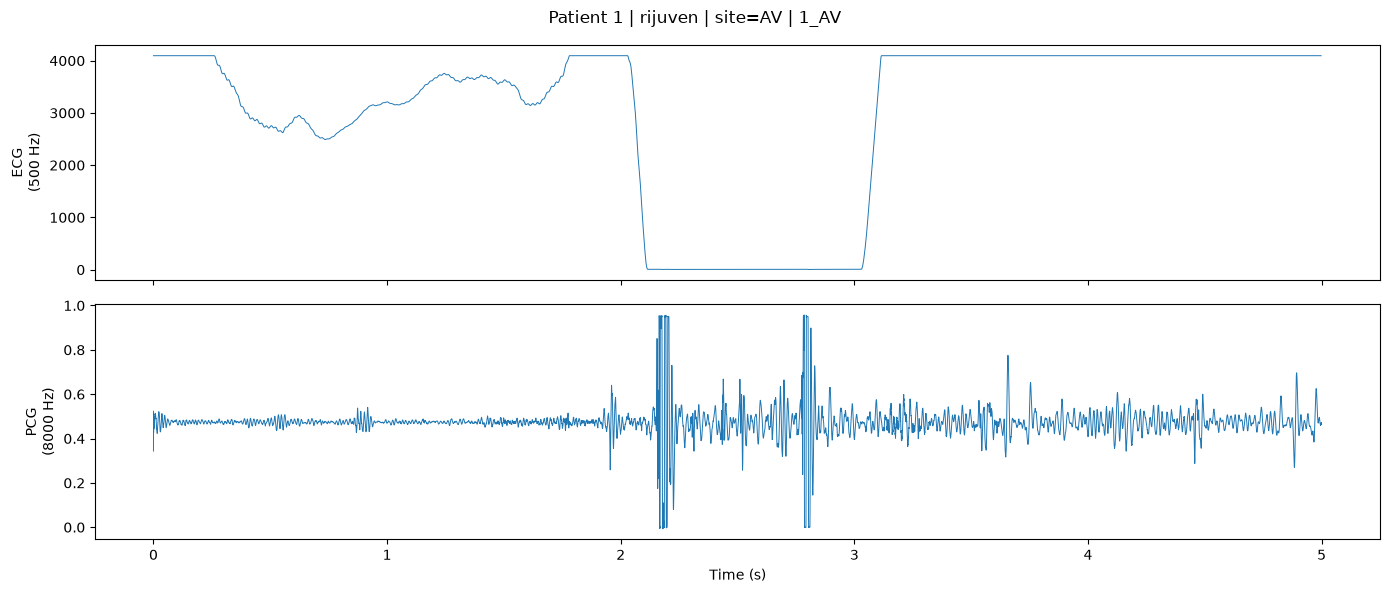

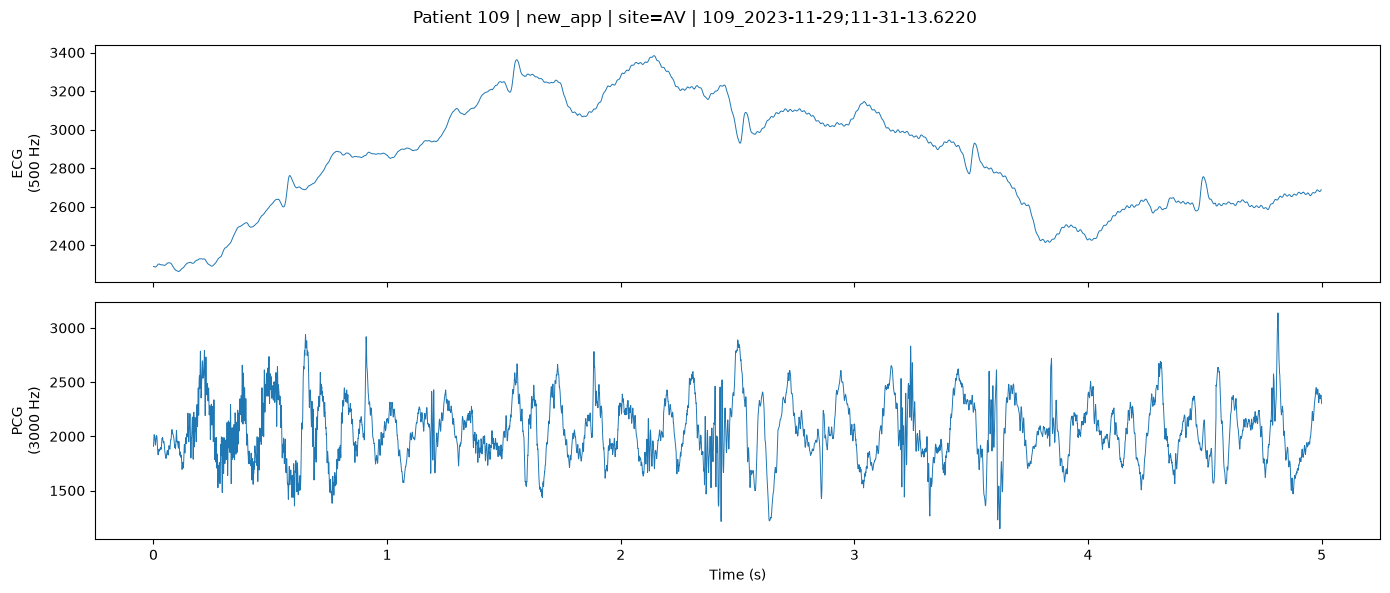

In [20]:
# Quick visual check: one recording from each app
for source in ("rijuven", "new_app"):
    subset = index[index["source"] == source]
    if len(subset):
        plot_recording(load_recording(subset.iloc[0]))

### 11. Dataset summary
[[go back to the top]](#table-of-contents)

Loads every recording once and reports duration, sampling rate and quality flags.
Decoding all the MP3s can take a few minutes; set `LIMIT` to a small number for a quick test.

In [24]:
LIMIT = None  # e.g. 10 for a quick test

rows, errors = [], []
for _, row in index.head(LIMIT).iterrows() if LIMIT else index.iterrows():
    try:
        rec = load_recording(row)
    except Exception as exc:
        errors.append((row["recording_id"], repr(exc)))
        continue
    entry = {"patient": rec.patient, "source": rec.source, "site": rec.site, "recording_id": rec.recording_id}
    for name, sig in (("ecg", rec.ecg), ("pcg", rec.pcg)):
        entry[f"{name}_fs"] = sig.fs if sig else np.nan
        entry[f"{name}_duration_s"] = round(sig.duration(), 2) if sig else np.nan
        entry[f"{name}_packet_gaps"] = sig.meta.get("packet_gaps", np.nan) if sig else np.nan
    if rec.pcg is not None and rec.source == "new_app":
        entry["pcg_clip_frac"] = float(np.mean((rec.pcg.data <= 0) | (rec.pcg.data >= NEW_APP_ADC_MAX)))
    rows.append(entry)

summary = pd.DataFrame(rows)
summary["duration_diff_s"] = (summary["ecg_duration_s"] - summary["pcg_duration_s"]).round(2)

print(f"Loaded: {len(summary)}  |  Errors: {len(errors)}")
for rid, err in errors[:20]:
    print("  ", rid, err)

summary.describe(include="all").T

Loaded: 1353  |  Errors: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
patient,1353.0,NaN,NaN,NaN,160.574279,85.347223,1.0,92.0,170.0,231.0,301.0
source,1353,2,new_app,933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
site,1353,4,AV,350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
recording_id,1353,1353,1_AV,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ecg_fs,1353.0,NaN,NaN,NaN,500.0,0.0,500.0,500.0,500.0,500.0,500.0
ecg_duration_s,1353.0,NaN,NaN,NaN,27.948078,3.404231,3.5,27.5,29.0,30.75,31.0
ecg_packet_gaps,933.0,NaN,NaN,NaN,5.595927,9.250256,0.0,0.0,1.0,6.0,51.0
pcg_fs,1353.0,NaN,NaN,NaN,4552.10643,2314.185816,3000.0,3000.0,3000.0,8000.0,8000.0
pcg_duration_s,1353.0,NaN,NaN,NaN,27.948078,3.404231,3.5,27.5,29.0,30.75,31.0
pcg_packet_gaps,933.0,NaN,NaN,NaN,5.572347,9.243044,0.0,0.0,1.0,6.0,50.0


In [25]:
# Recordings that deserve a closer look
summary[
    (summary["duration_diff_s"].abs() > 1)
    | (summary["ecg_packet_gaps"] > 0)
    | (summary["pcg_packet_gaps"] > 0)
    | (summary.get("pcg_clip_frac", pd.Series(0, index=summary.index)) > 0.01)
]

,patient,source,site,recording_id,ecg_fs,ecg_duration_s,ecg_packet_gaps,pcg_fs,pcg_duration_s,pcg_packet_gaps,pcg_clip_frac,duration_diff_s
405,109,new_app,PV,109_2023-11-29;11-32-08.3030,500.0,29.00,1.0,3000.0,29.00,1.0,0.003713,0.0
410,110,new_app,TV,110_2023-11-29;11-44-54.1280,500.0,24.25,15.0,3000.0,24.25,15.0,0.013251,0.0
411,110,new_app,MV,110_2023-11-29;11-45-41.6320,500.0,29.00,0.0,3000.0,29.00,0.0,0.014126,0.0
412,111,new_app,AV,111_2023-11-30;09-57-03.9270,500.0,26.00,8.0,3000.0,26.00,8.0,0.000692,0.0
413,111,new_app,PV,111_2023-11-30;09-58-25.9340,500.0,29.25,0.0,3000.0,29.25,0.0,0.074701,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1347,301,new_app,AV,301_2026-07-21;17-44-11.2670,500.0,28.00,2.0,3000.0,28.00,2.0,0.008929,0.0
1349,301,new_app,TV,301_2026-07-21;17-49-44.9060,500.0,26.50,4.0,3000.0,26.50,4.0,0.000000,0.0
1350,301,new_app,TV,301_2026-07-21;17-50-45.6170,500.0,24.50,9.0,3000.0,24.50,8.0,0.000558,0.0
1351,301,new_app,MV,301_2026-07-21;17-53-54.7750,500.0,25.50,7.0,3000.0,25.50,6.0,0.000026,0.0
